In [2]:
import numpy as np
from torchvision import datasets
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import time

# Loading the MNIST from torchvision package (Fashion-MNIST dataset)

train_data = datasets.FashionMNIST('./data/fashion_mnist', train=True, download=True)
test_data = datasets.FashionMNIST('./data/fashion_mnist', train=False, download=True)

# Flatten MNIST to 1D vectors (28*28 = 784) and normalize (0 to 1)
# because SVM can't handle images in 2D type

# train part
X_train = train_data.data.numpy().reshape(-1, 784) / 255.0
y_train = train_data.targets.numpy()

#test part
X_test = test_data.data.numpy().reshape(-1, 784) / 255.0
y_test = test_data.targets.numpy()

#  Initializing and training
# This may take a while on the full dataset since it's supposed to be 60k images
print("Starting SVM training... ")
start_time = time.time()

svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train, y_train)

print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# Predictions on the Test Set
# I did this based on a video on SVM training I found
print("Generating predictions...")
y_pred = svm_model.predict(X_test)

# Performance Evaluation (Extracting Accuracy, Precision, Recall, and F1-Score)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall SVM Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Report (Precision, Recall, F1-Score):")
# target_names represent the 10 classes in Fashion-MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(classification_report(y_test, y_pred, target_names=classes))

Starting SVM training... (This may take a while on the full dataset)
Training completed in 349.47 seconds.
Generating predictions...

Overall SVM Accuracy: 90.02%

Detailed Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.84      0.82      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.83      0.83      0.83      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.75      0.72      0.73      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



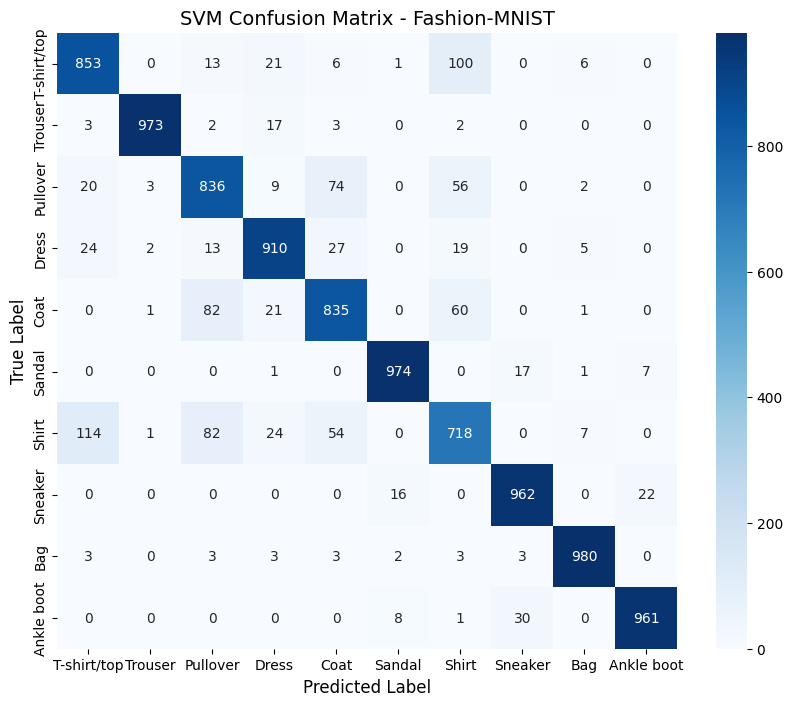

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
# Using seaborn to make the heatmap look professional for your presentation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('SVM Confusion Matrix - Fashion-MNIST', fontsize=14)
plt.show()

print("\n" + "="*50 + "\n")



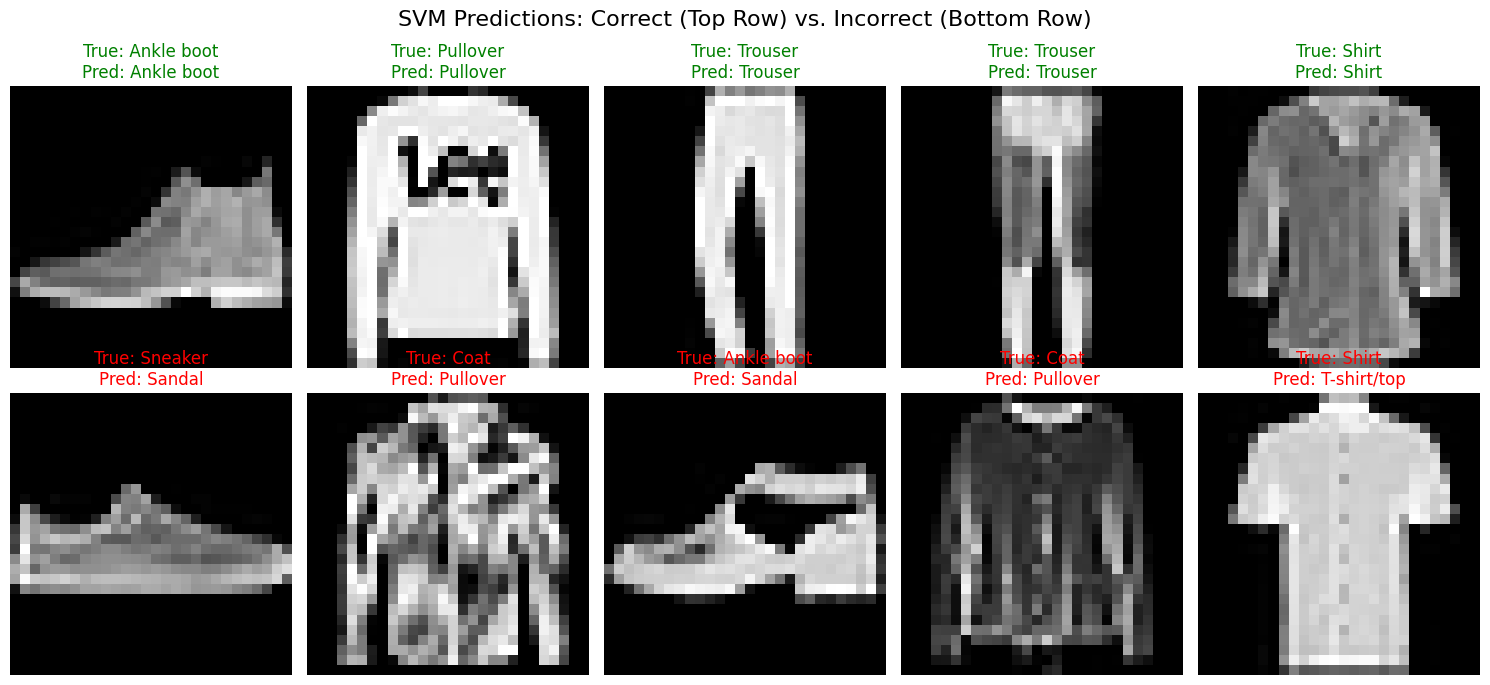

In [5]:
# 2. Visualizing Correct vs. Incorrect Predictions
# Find indices of correct and incorrect predictions
correct_indices = np.nonzero(y_pred == y_test)[0]
incorrect_indices = np.nonzero(y_pred != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('SVM Predictions: Correct (Top Row) vs. Incorrect (Bottom Row)', fontsize=16)

# Plot 5 Correct Predictions
for i, ax in enumerate(axes[0]):
    idx = correct_indices[i]
    # We must reshape the flattened 784 1D array back into a 28x28 2D image
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {classes[y_test[idx]]}\nPred: {classes[y_pred[idx]]}", color='green')
    ax.axis('off')

# Plot 5 Incorrect Predictions
for i, ax in enumerate(axes[1]):
    idx = incorrect_indices[i]
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {classes[y_test[idx]]}\nPred: {classes[y_pred[idx]]}", color='red')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()